# enhanced-v5 — Fund Flow Prediction Pipeline

**Best techniques from all previous notebooks (v1–v4 + grok-v1/v2), systematically combined.**

| What's new vs v4 | Source |
|---|---|
| Uses `kse30_index_level.csv` (proper log returns) | Bug fix #1 |
| Drops 2020 rows (no fabricated macro via bfill) | v2 fix, reverted in v3/v4 |
| 12 features: multi-lag, volatility, abnormal volume, CPI, first-diff macros | v2 + grok-v1 + v4 |
| 4 models: ElasticNet (new), Ridge, GradientBoosting, XGBoost | best from all versions |
| TimeSeriesSplit(5) + Directional Accuracy metric | v3 fix |
| 6-month ensemble forecast | v4 |
| Market efficiency tests (Hurst + Variance Ratio) | grok-v1 |
| All plots saved to `v5/output/` | new |

> ⚠ **Directional signal only** — magnitude estimates unreliable at ~47 training rows.


## 0. Imports & Configuration

In [5]:
import os, warnings
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print("lightgbm not installed — using XGBoost only for tree models.")

warnings.filterwarnings('ignore')
%matplotlib inline

# ── CONFIG ────────────────────────────────────────────────────────────────────
RANDOM_STATE    = 42
N_SPLITS        = 5
FORECAST_MONTHS = 6
SAVE_PLOTS      = True

try:
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    BASE_DIR = os.path.abspath('.')   # Jupyter: run from new-pipeline/v5/

DATA_DIR = os.path.normpath(os.path.join(BASE_DIR, '..', 'data'))
OUT_DIR  = os.path.join(BASE_DIR, 'output')
os.makedirs(OUT_DIR, exist_ok=True)
print(f"Data  : {DATA_DIR}")
print(f"Output: {OUT_DIR}")

Data  : d:\roohan\fyp-indexfunds\enhanced\data
Output: d:\roohan\fyp-indexfunds\enhanced\v5\output


## 1. Helper Functions

In [6]:
def save_fig(name: str):
    if SAVE_PLOTS:
        path = os.path.join(OUT_DIR, f'{name}.png')
        plt.savefig(path, dpi=150, bbox_inches='tight')
        print(f"  → saved: {path}")
    plt.show()

def excel_to_datetime(serial):
    try:
        return datetime(1899, 12, 30) + timedelta(days=int(serial))
    except (ValueError, TypeError):
        return pd.NaT

def parse_date_col(series: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(series):
        return series.apply(excel_to_datetime)
    return pd.to_datetime(series, errors='coerce')

def directional_accuracy(y_true, y_pred) -> float:
    return float(np.mean(np.sign(y_true) == np.sign(y_pred)) * 100)

def hurst_exponent(ts, max_lag=20):
    lags = range(2, min(max_lag, len(ts) // 2))
    tau  = [np.std(np.subtract(ts[lag:], ts[:-lag])) for lag in lags]
    return float(np.polyfit(np.log(list(lags)), np.log(tau), 1)[0])

def variance_ratio(ts, q=3):
    mu   = np.mean(ts)
    var1 = np.var(ts - mu, ddof=1)
    ts_q = [ts[i] - ts[i - q] - q * mu for i in range(q, len(ts))]
    return float(np.var(ts_q, ddof=1) / (q * var1))

print("Helpers defined.")


Helpers defined.


## 2. KSE-30 Index Data

Uses `kse30_index_level.csv` — a pre-computed daily dataset with proper `log_return`,
`total_volume`, and `avg_weight_change`. This **fixes Bug #1** from v1–v4 where
`weighted_price` was incorrectly used as a return proxy.

New features computed here before any lagging to avoid leakage:
- `vol3_return` — 3-month rolling std of monthly log return (volatility signal)
- `abnorm_vol` — monthly volume / 3-month rolling avg (institutional activity signal, from grok-v1)


In [7]:
kse_daily = pd.read_csv(
    os.path.join(DATA_DIR, 'kse30_index_level.csv'), parse_dates=['date']
)
kse_daily = kse_daily.drop_duplicates(subset=['date']).sort_values('date').reset_index(drop=True)

kse_monthly = (
    kse_daily.set_index('date').resample('ME').agg(
        log_return        = ('log_return', 'sum'),
        total_volume      = ('total_volume', 'sum'),
        avg_weight_change = ('avg_weight_change', 'mean'),
    ).reset_index()
)

kse_monthly['vol3_return']  = kse_monthly['log_return'].rolling(3).std()
kse_monthly['avg3m_volume'] = kse_monthly['total_volume'].rolling(3).mean()
kse_monthly['abnorm_vol']   = kse_monthly['total_volume'] / kse_monthly['avg3m_volume']

print(f"KSE-30 monthly: {len(kse_monthly)} rows")
print(f"Date range    : {kse_monthly['date'].min().date()} → {kse_monthly['date'].max().date()}")
kse_monthly.tail(3)


KSE-30 monthly: 70 rows
Date range    : 2020-01-31 → 2025-10-31


,date,log_return,total_volume,avg_weight_change,vol3_return,avg3m_volume,abnorm_vol
67,2025-08-31,8.049525,2.750282e+09,0.033060,0.649809,2.245045e+09,1.225045
68,2025-09-30,8.230679,4.395377e+09,0.031748,0.673045,3.085366e+09,1.424589
69,2025-10-31,0.408713,4.334543e+08,0.030700,4.464639,2.526371e+09,0.171572


## 3. Company-Level Data (Portfolio Selection)

In [8]:
co_raw = pd.read_excel(os.path.join(DATA_DIR, 'kse-30-basic.xlsx'))
co_raw.columns = co_raw.columns.str.strip().str.lower().str.replace(r'\s+', '_', regex=True)
co_raw = co_raw.rename(columns={'idx_wt_%': 'idx_wt', 'date': 'date_raw'})
co_raw['date'] = parse_date_col(co_raw['date_raw'])
co_raw = (co_raw
          .dropna(subset=['date', 'company', 'price'])
          .drop_duplicates(subset=['date', 'company'])
          .sort_values(['company', 'date']))

co_raw['month'] = co_raw['date'].dt.to_period('M')
company_monthly = co_raw.groupby(['company', 'month'])['price'].last().reset_index()
company_monthly['return']   = company_monthly.groupby('company')['price'].pct_change()
company_monthly['month_dt'] = company_monthly['month'].dt.to_timestamp('M')

print(f"{co_raw['company'].nunique()} companies | "
      f"{co_raw['date'].min().date()} → {co_raw['date'].max().date()}")


59 companies | 2020-01-01 → 2025-10-01


## 4. Fund Flow Computation

Formula: `flow_t = AUM_t − AUM_{t-1} × (NAV_t / NAV_{t-1})`

This isolates net new investor money from performance-driven AUM changes.
Combined across AKD, NBP, and NTI, then summed monthly.


In [9]:
flow_frames = []
for fund_name in ['AKD', 'NBP', 'NTI']:
    fdf = pd.read_excel(os.path.join(DATA_DIR, 'funds_data.xlsx'), sheet_name=fund_name)
    fdf.columns = fdf.columns.str.strip().str.upper()
    fdf['date'] = parse_date_col(fdf['DATE'])
    fdf = fdf.dropna(subset=['date', 'NAV', 'AUM']).sort_values('date')
    fdf['nav_ratio'] = fdf['NAV'] / fdf['NAV'].shift(1)
    fdf['flow']      = fdf['AUM'] - (fdf['AUM'].shift(1) * fdf['nav_ratio'])
    flow_frames.append(fdf[['date', 'flow']])
    print(f"  {fund_name}: {len(fdf)} daily rows")

monthly_flow = (
    pd.concat(flow_frames, ignore_index=True)
    .set_index('date').resample('ME')['flow']
    .sum().reset_index(name='total_fund_flow')
)
monthly_flow['total_fund_flow'] = monthly_flow['total_fund_flow'].fillna(0)
print(f"\nMonthly flow rows: {len(monthly_flow)}")
monthly_flow.tail(3)


  AKD: 1643 daily rows
  NBP: 1922 daily rows
  NTI: 2127 daily rows

Monthly flow rows: 71


,date,total_fund_flow
68,2025-11-30,-5.758869
69,2025-12-31,208.859375
70,2026-01-31,-78.937860


## 5. Macro Data (OIL, IR, USD, CPI)

In [10]:
# Oil
oil         = pd.read_excel(os.path.join(DATA_DIR, 'macro_data.xlsx'), sheet_name='OIL')
oil['date'] = parse_date_col(oil['DATE'])
oil_monthly = (oil.dropna(subset=['date']).set_index('date').resample('ME')['PRICE']
               .last().reset_index().rename(columns={'PRICE': 'oil_price'}))

# Interest Rate — step function, forward fill to daily before monthly resample
ir          = pd.read_excel(os.path.join(DATA_DIR, 'macro_data.xlsx'), sheet_name='IR')
ir['date']  = parse_date_col(ir['DATE'])
ir          = ir.dropna(subset=['date']).set_index('date').sort_index()
ir_daily    = ir.reindex(pd.date_range(ir.index.min(), ir.index.max(), freq='D')).ffill()
ir_monthly  = (ir_daily['RATE'].resample('ME').last()
               .reset_index().rename(columns={'index': 'date', 'RATE': 'interest_rate'}))

# USD
usd         = pd.read_excel(os.path.join(DATA_DIR, 'macro_data.xlsx'), sheet_name='USD')
usd['date'] = parse_date_col(usd['DATE'])
usd_monthly = (usd.dropna(subset=['date']).set_index('date').resample('ME')['USD']
               .last().reset_index().rename(columns={'USD': 'usd_exchange'}))

# CPI
cpi_raw           = pd.read_csv(os.path.join(DATA_DIR, 'cpi.csv'), skiprows=1,
                                 header=None, names=['period', 'yoy_cpi'])
cpi_raw           = cpi_raw[cpi_raw['period'] != 'Period'].dropna()
cpi_raw['date']   = pd.to_datetime('01-' + cpi_raw['period'].astype(str),
                                    format='%d-%b-%y', errors='coerce')
cpi_raw['yoy_cpi'] = pd.to_numeric(cpi_raw['yoy_cpi'], errors='coerce')
cpi_monthly       = (cpi_raw.dropna(subset=['date', 'yoy_cpi'])
                     .set_index('date').resample('ME')['yoy_cpi']
                     .last().reset_index().rename(columns={'yoy_cpi': 'cpi'}))

print(f"IR  coverage: {ir_monthly['date'].min().date()} → {ir_monthly['date'].max().date()}")
print(f"CPI coverage: {cpi_monthly['date'].min().date()} → {cpi_monthly['date'].max().date()}")

IR  coverage: 2021-09-30 → 2025-12-31
CPI coverage: 2018-07-31 → 2026-01-31


## 6. Merge, Filter & Winsorise

**Key decisions (from v2):**
- `ffill()` only — no `bfill`, which would fabricate macro values before 2021
- Drop `year < 2021` — macro data starts 2021; all earlier macro rows are extrapolated
- Winsorise fund flows at ±3σ — handles the April 2022 political event outlier (−62.7 PKR bn)


In [11]:
df = kse_monthly.copy()
for src in [monthly_flow, oil_monthly, ir_monthly, usd_monthly, cpi_monthly]:
    df = df.merge(src, on='date', how='left')

for col in ['oil_price', 'interest_rate', 'usd_exchange', 'cpi']:
    df[col] = df[col].ffill()
df['total_fund_flow'] = df['total_fund_flow'].fillna(0)

# Drop pre-2021
df = df[df['date'].dt.year >= 2021].reset_index(drop=True)
print(f"After 2020 drop: {len(df)} rows  ({df['date'].min().date()} → {df['date'].max().date()})")

# Winsorise
mean_flow = df['total_fund_flow'].mean()
std_flow  = df['total_fund_flow'].std()
lower_w, upper_w = mean_flow - 3*std_flow, mean_flow + 3*std_flow
n_clip = int(((df['total_fund_flow'] < lower_w) | (df['total_fund_flow'] > upper_w)).sum())
df['total_fund_flow'] = df['total_fund_flow'].clip(lower=lower_w, upper=upper_w)
print(f"Winsorised {n_clip} rows  [bounds: {lower_w:.0f}, {upper_w:.0f}]")

check_cols = ['total_fund_flow','oil_price','interest_rate','usd_exchange','cpi',
              'log_return','total_volume','vol3_return','abnorm_vol']
display(df[check_cols].isnull().sum().to_frame('NaN count').T)


After 2020 drop: 58 rows  (2021-01-31 → 2025-10-31)
Winsorised 1 rows  [bounds: -798, 734]


,total_fund_flow,oil_price,interest_rate,usd_exchange,cpi,log_return,total_volume,vol3_return,abnorm_vol
NaN count,0,0,8,2,0,0,0,0,0


## 7. Feature Engineering (12 Features)

| Feature | Source | Rationale |
|---|---|---|
| `lag1_volume`, `lag3_volume` | KSE-30 | Trading activity 1 and 3 months ago |
| `lag1_return`, `lag3_return` | KSE-30 | Market performance signal + trend |
| `lag1_vol3_ret` | KSE-30 | Return volatility — deters flow |
| `lag1_abnorm_vol` | KSE-30 | Relative trading pressure (from grok-v1) |
| `lag1_ir`, `lag1_ir_change` | IR | Level + direction of rate cycle (from v2) |
| `lag1_oil` | OIL | Global macro |
| `lag1_usd`, `lag1_usd_pct` | USD | Level + direction of currency pressure (from v2) |
| `lag1_cpi` | CPI | Inflation eats real returns (from v4) |


In [12]:
df['lag1_volume']     = df['total_volume'].shift(1)
df['lag3_volume']     = df['total_volume'].shift(3)
df['lag1_return']     = df['log_return'].shift(1)
df['lag3_return']     = df['log_return'].shift(3)
df['lag1_vol3_ret']   = df['vol3_return'].shift(1)
df['lag1_abnorm_vol'] = df['abnorm_vol'].shift(1)
df['lag1_ir']         = df['interest_rate'].shift(1)
df['lag1_oil']        = df['oil_price'].shift(1)
df['lag1_usd']        = df['usd_exchange'].shift(1)
df['lag1_cpi']        = df['cpi'].shift(1)
df['lag1_ir_change']  = df['interest_rate'].diff().shift(1)
df['lag1_usd_pct']    = df['usd_exchange'].pct_change().shift(1)

FEATURES = [
    'lag1_volume', 'lag3_volume',
    'lag1_return', 'lag3_return',
    'lag1_vol3_ret', 'lag1_abnorm_vol',
    'lag1_ir', 'lag1_ir_change',
    'lag1_oil',
    'lag1_usd', 'lag1_usd_pct',
    'lag1_cpi',
]
TARGET = 'total_fund_flow'

model_df = df.dropna(subset=FEATURES + [TARGET]).reset_index(drop=True)
X = model_df[FEATURES].values
y = model_df[TARGET].values

print(f"Feature matrix : {model_df.shape[0]} rows × {len(FEATURES)} features")
print(f"Usable window  : {model_df['date'].min().date()} → {model_df['date'].max().date()}")


Feature matrix : 48 rows × 12 features
Usable window  : 2021-11-30 → 2025-10-31


## 8. Correlation Heatmap

  → saved: d:\roohan\fyp-indexfunds\enhanced\v5\output\01_correlation_heatmap.png


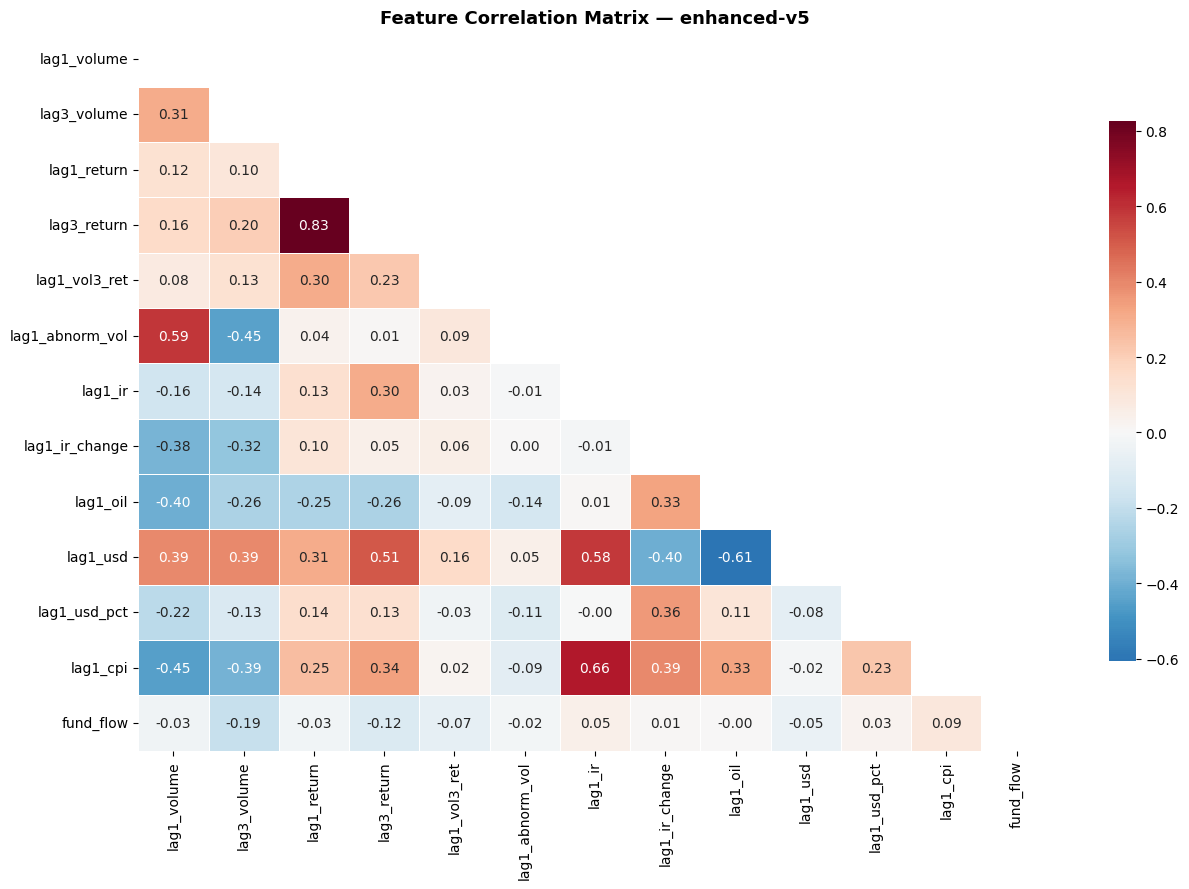

In [13]:
fig, ax = plt.subplots(figsize=(13, 9))
corr_data   = model_df[FEATURES + [TARGET]].copy()
corr_data.columns = FEATURES + ['fund_flow']
corr_matrix = corr_data.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.75})
ax.set_title('Feature Correlation Matrix — enhanced-v5', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('01_correlation_heatmap')


## 9. Fund Flow History

  → saved: d:\roohan\fyp-indexfunds\enhanced\v5\output\02_fund_flow_history.png


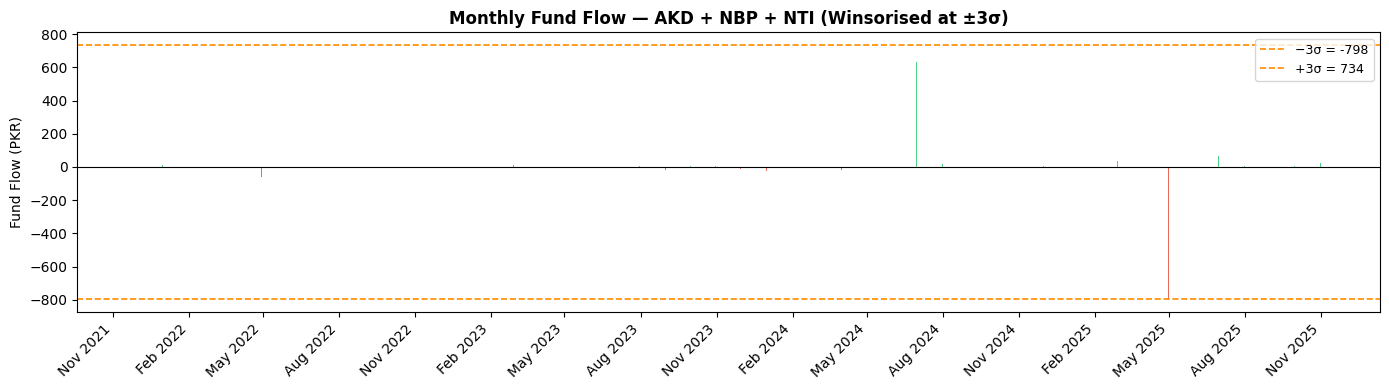

In [14]:
fig, ax = plt.subplots(figsize=(14, 4))
colors_bar = np.where(model_df[TARGET] >= 0, '#2ecc71', '#e74c3c')
ax.bar(model_df['date'], model_df[TARGET], color=colors_bar, edgecolor='none', alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(lower_w, color='darkorange', linewidth=1.2, linestyle='--', label=f'−3σ = {lower_w:.0f}')
ax.axhline(upper_w, color='darkorange', linewidth=1.2, linestyle='--', label=f'+3σ = {upper_w:.0f}')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')
ax.set_title('Monthly Fund Flow — AKD + NBP + NTI (Winsorised at ±3σ)', fontsize=12, fontweight='bold')
ax.set_ylabel('Fund Flow (PKR)')
ax.legend(fontsize=9)
plt.tight_layout()
save_fig('02_fund_flow_history')


## 10. Model Suite

| Model | Type | Regularisation | Why |
|---|---|---|---|
| **ElasticNet** | Linear | L1 + L2 | New to this series — auto feature selection + stability |
| **Ridge** | Linear | L2 | Proven baseline from v2/v3/v4 |
| **GradientBoosting** | Tree | Shallow depth=2 | Conservative trees for small data |
| **XGBoost** | Tree | alpha + lambda | Strong regularisation for ~47 rows |
| **LightGBM** | Tree | num_leaves + reg | Best tree model if installed |

LSTM dropped — not viable with 1 timestep and ~47 rows (see v4 failure: RMSE 188,366).


In [15]:
MODEL_COLORS = ['#e74c3c', '#3498db', '#9b59b6', '#27ae60', '#f39c12']

models = {
    'ElasticNet': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10_000, random_state=RANDOM_STATE)),
    ]),
    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  Ridge(alpha=1.0)),
    ]),
    'GradBoost': GradientBoostingRegressor(
        n_estimators=50, max_depth=2, learning_rate=0.05,
        subsample=0.8, random_state=RANDOM_STATE,
    ),
    'XGBoost': XGBRegressor(
        n_estimators=100, max_depth=3, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=1.0, reg_lambda=1.0,
        random_state=RANDOM_STATE, verbosity=0,
    ),
}

if HAS_LGB:
    models['LightGBM'] = lgb.LGBMRegressor(
        n_estimators=100, num_leaves=15, min_child_samples=5,
        reg_alpha=1.0, reg_lambda=1.0, learning_rate=0.05,
        random_state=RANDOM_STATE, verbose=-1,
    )

MODEL_NAMES = list(models.keys())
print(f"Active models: {MODEL_NAMES}")


Active models: ['ElasticNet', 'Ridge', 'GradBoost', 'XGBoost', 'LightGBM']


## 11. TimeSeriesSplit Cross-Validation

Using `TimeSeriesSplit(n_splits=5)` — respects temporal order, no data leakage.
Three metrics per fold: **RMSE**, **MAE**, **Directional Accuracy** (most investment-relevant).


In [16]:
tscv = TimeSeriesSplit(n_splits=N_SPLITS)
cv_results = {name: {'rmse': [], 'mae': [], 'dir_acc': []} for name in MODEL_NAMES}
fold_preds  = {name: [] for name in MODEL_NAMES}

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X)):
    X_tr, X_val = X[tr_idx], X[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]
    dates_val   = model_df['date'].iloc[val_idx].values
    for name, mdl in models.items():
        mdl.fit(X_tr, y_tr)
        preds = mdl.predict(X_val)
        cv_results[name]['rmse'].append(np.sqrt(mean_squared_error(y_val, preds)))
        cv_results[name]['mae'].append(mean_absolute_error(y_val, preds))
        cv_results[name]['dir_acc'].append(directional_accuracy(y_val, preds))
        fold_preds[name].append((dates_val, y_val, preds))

summary = pd.DataFrame({
    name: {
        'Mean RMSE': f"{np.mean(v['rmse']):.1f}",
        'Std RMSE':  f"{np.std(v['rmse']):.1f}",
        'Mean MAE':  f"{np.mean(v['mae']):.1f}",
        'Dir Acc %': f"{np.mean(v['dir_acc']):.1f}",
    } for name, v in cv_results.items()
}).T
display(summary)


,Mean RMSE,Std RMSE,Mean MAE,Dir Acc %
ElasticNet,165.3,134.7,95.1,52.5
Ridge,168.3,132.2,101.6,47.5
GradBoost,175.7,138.8,104.0,52.5
XGBoost,187.5,147.3,115.3,47.5
LightGBM,152.2,150.1,83.5,45.0


### CV Fold Predictions

  → saved: d:\roohan\fyp-indexfunds\enhanced\v5\output\03_tscv_folds.png


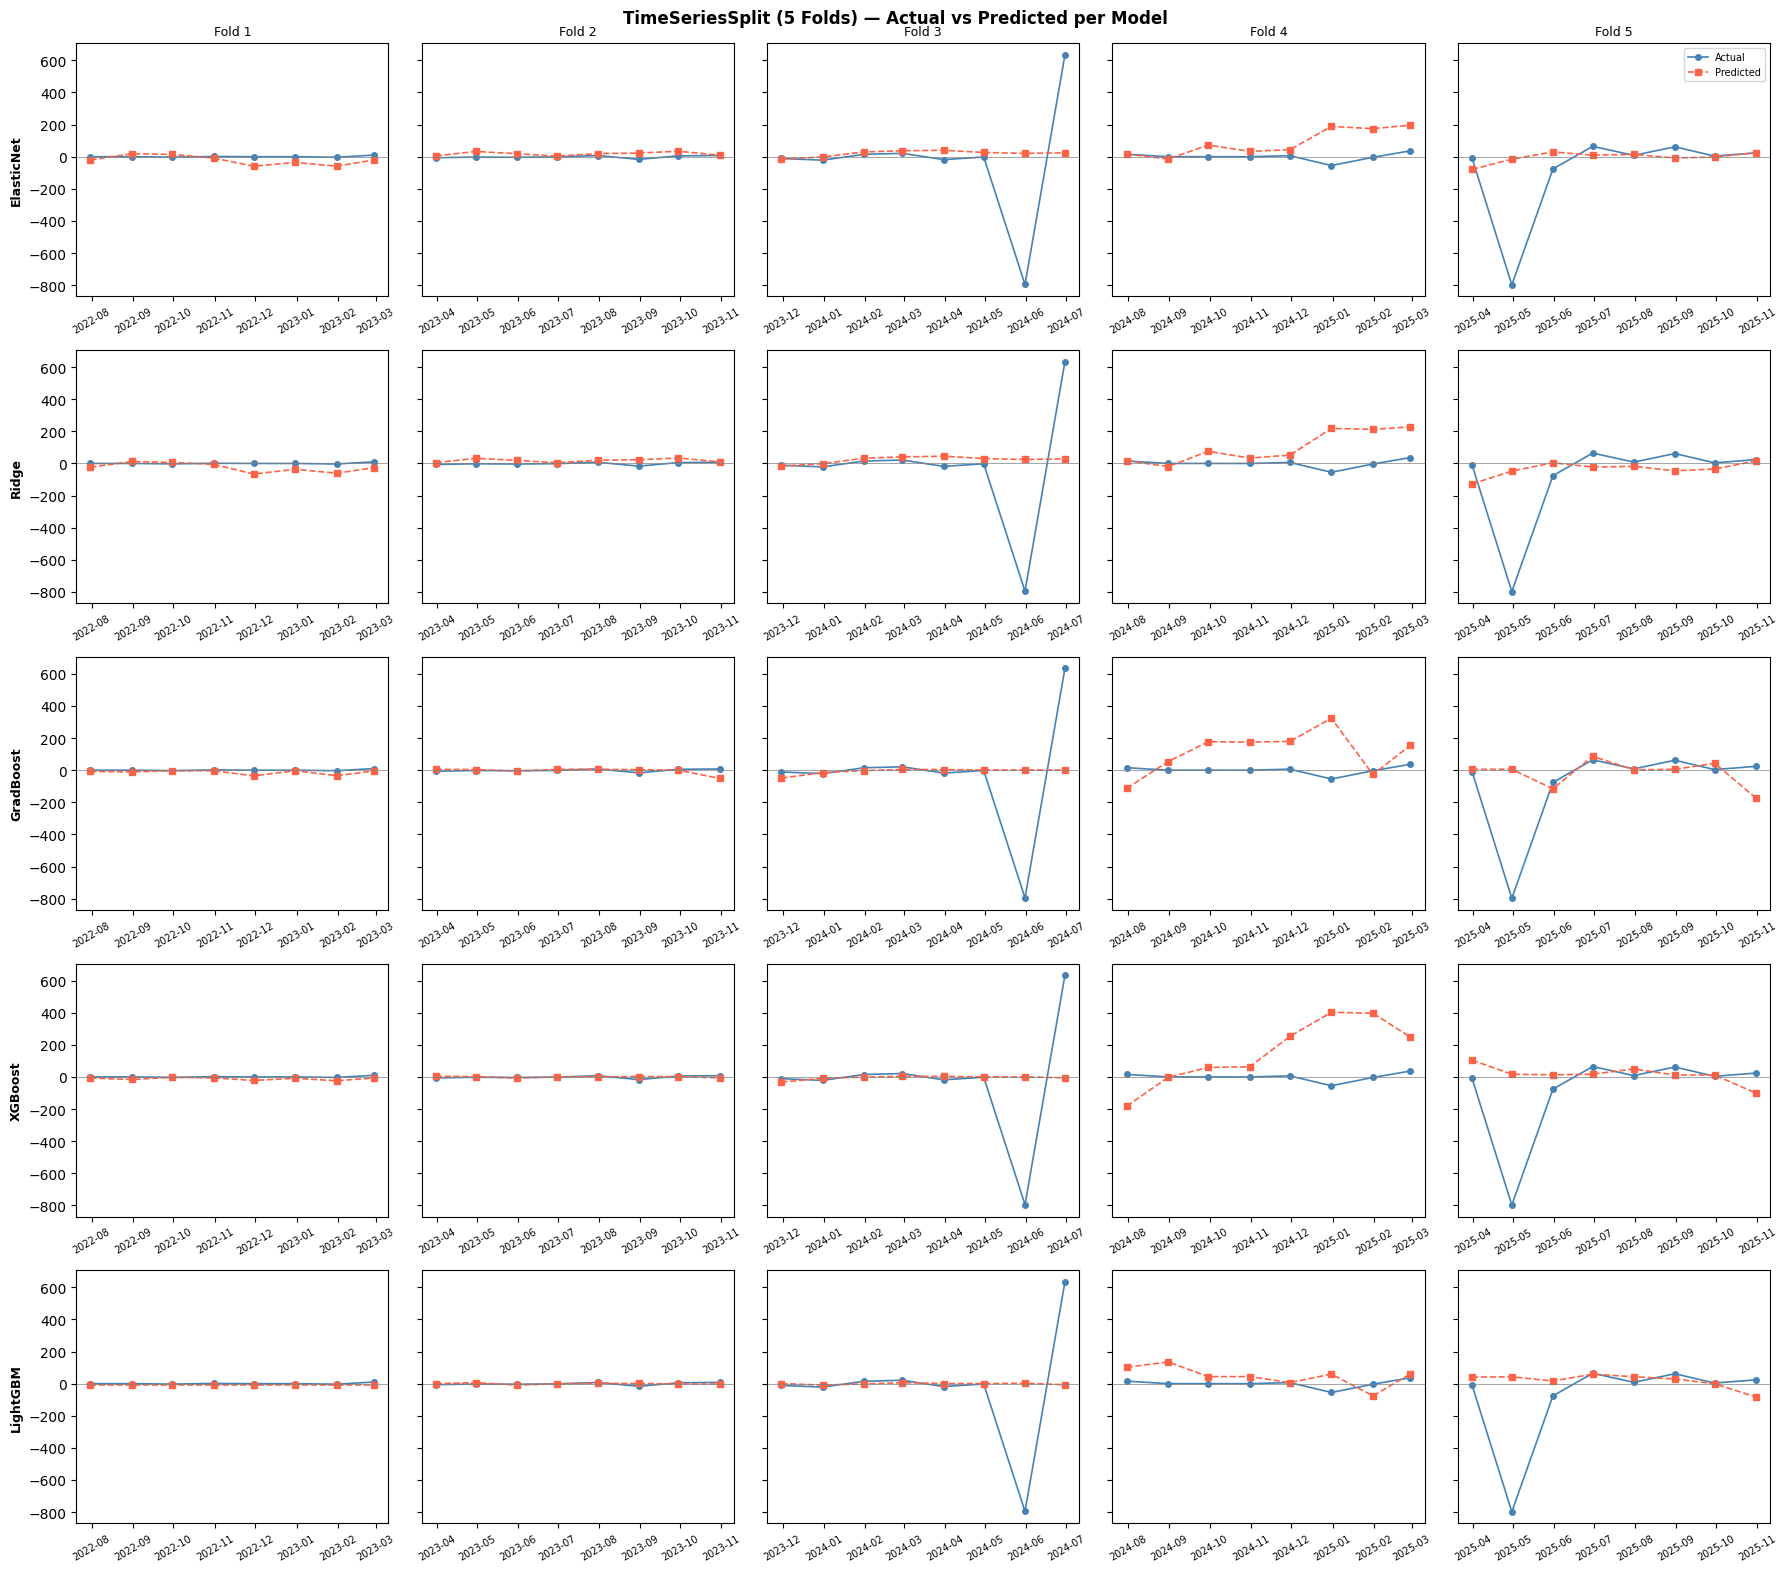

In [17]:
n_m = len(MODEL_NAMES)
fig, axes = plt.subplots(n_m, N_SPLITS, figsize=(18, 3.2*n_m), sharey=True)
for mi, name in enumerate(MODEL_NAMES):
    for fi, (dv, yv, pv) in enumerate(fold_preds[name]):
        ax = axes[mi][fi]
        ax.plot(dv, yv, 'o-', color='steelblue',  markersize=4, linewidth=1.2, label='Actual')
        ax.plot(dv, pv, 's--', color='tomato',    markersize=4, linewidth=1.2, label='Predicted')
        ax.axhline(0, color='gray', linewidth=0.5)
        if mi == 0:
            ax.set_title(f'Fold {fi+1}', fontsize=9)
        ax.tick_params(axis='x', rotation=30, labelsize=7)
        if fi == 0:
            ax.set_ylabel(name, fontsize=9, fontweight='bold')
        if mi == 0 and fi == N_SPLITS - 1:
            ax.legend(fontsize=7)
fig.suptitle(f'TimeSeriesSplit ({N_SPLITS} Folds) — Actual vs Predicted per Model',
             fontsize=12, fontweight='bold')
plt.tight_layout()
save_fig('03_tscv_folds')


## 12. Holdout Evaluation (Last 20%)

In [18]:
split_idx = int(len(X) * 0.8)
X_tr_h, X_te_h = X[:split_idx], X[split_idx:]
y_tr_h, y_te_h = y[:split_idx], y[split_idx:]
dates_te        = model_df['date'].iloc[split_idx:].values

holdout_preds, holdout_metrics = {}, {}
for name, mdl in models.items():
    mdl.fit(X_tr_h, y_tr_h)
    preds = mdl.predict(X_te_h)
    holdout_preds[name] = preds
    holdout_metrics[name] = {
        'RMSE':   round(float(np.sqrt(mean_squared_error(y_te_h, preds))), 1),
        'MAE':    round(float(mean_absolute_error(y_te_h, preds)), 1),
        'R²':     round(float(r2_score(y_te_h, preds)), 3),
        'DirAcc': round(directional_accuracy(y_te_h, preds), 1),
    }

display(pd.DataFrame(holdout_metrics).T.sort_values('RMSE'))


,RMSE,MAE,R²,DirAcc
Ridge,240.6,142.8,0.042,50.0
ElasticNet,243.7,127.4,0.018,50.0
LightGBM,248.2,123.5,-0.019,60.0
GradBoost,260.1,135.2,-0.119,60.0
XGBoost,262.5,139.0,-0.140,40.0


  → saved: d:\roohan\fyp-indexfunds\enhanced\v5\output\04_holdout_predictions.png


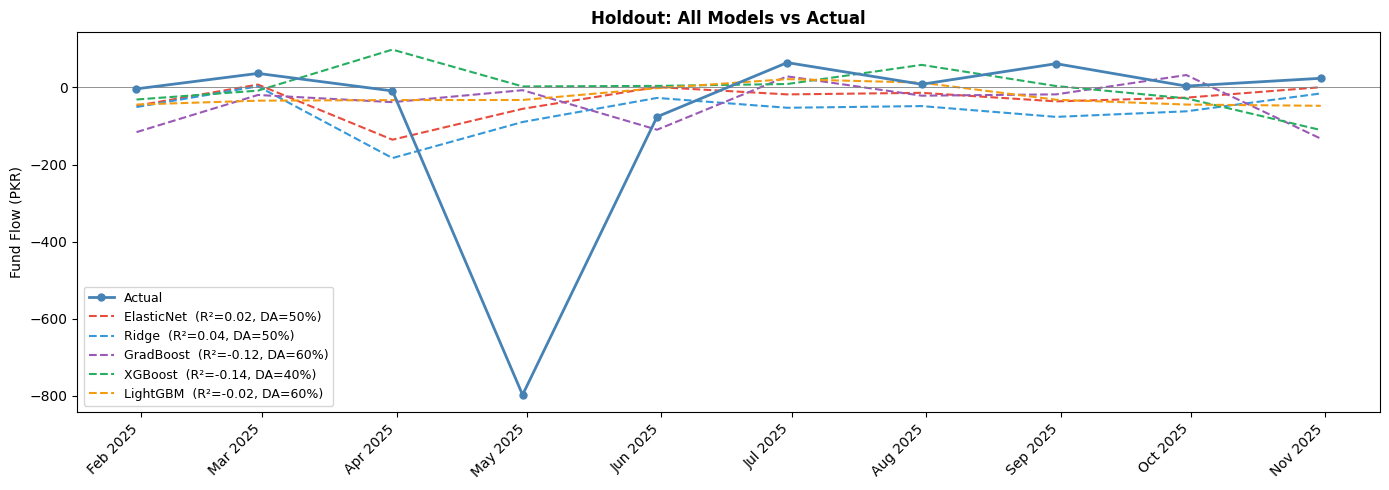

  → saved: d:\roohan\fyp-indexfunds\enhanced\v5\output\05_model_comparison.png


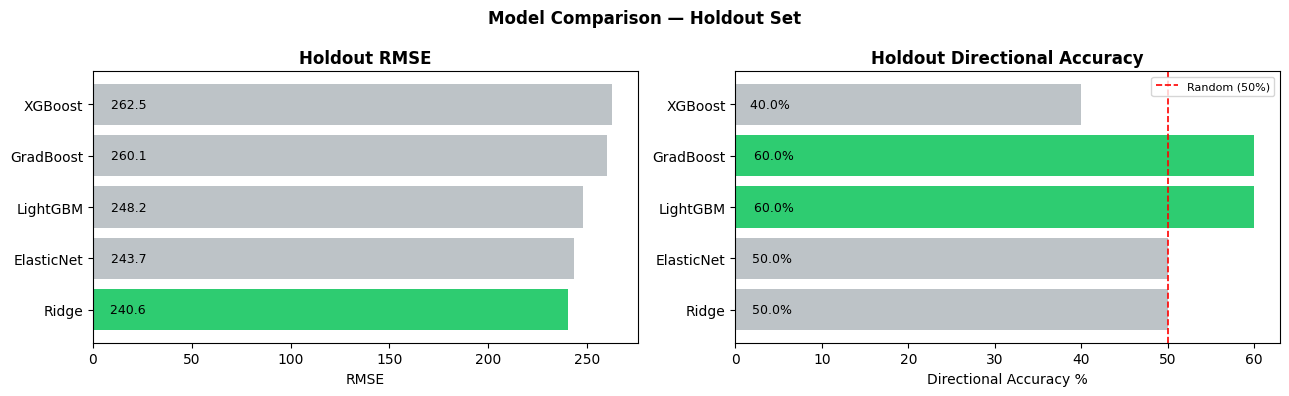

In [19]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dates_te, y_te_h, 'o-', color='steelblue', linewidth=2, markersize=5,
        label='Actual', zorder=5)
for (name, preds), color in zip(holdout_preds.items(), MODEL_COLORS):
    r2 = holdout_metrics[name]['R²']
    da = holdout_metrics[name]['DirAcc']
    ax.plot(dates_te, preds, '--', color=color, linewidth=1.5, markersize=4,
            label=f'{name}  (R²={r2:.2f}, DA={da:.0f}%)')
ax.axhline(0, color='gray', linewidth=0.6)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=45, ha='right')
ax.set_title('Holdout: All Models vs Actual', fontsize=12, fontweight='bold')
ax.set_ylabel('Fund Flow (PKR)')
ax.legend(fontsize=9)
plt.tight_layout()
save_fig('04_holdout_predictions')

# Comparison bar charts
names_s = sorted(MODEL_NAMES, key=lambda n: holdout_metrics[n]['RMSE'])
rmses   = [holdout_metrics[n]['RMSE']   for n in names_s]
daccs   = [holdout_metrics[n]['DirAcc'] for n in names_s]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
bc1 = ['#2ecc71' if i == 0 else '#bdc3c7' for i in range(len(names_s))]
ax1.barh(names_s, rmses, color=bc1, edgecolor='none')
ax1.set_xlabel('RMSE')
ax1.set_title('Holdout RMSE', fontweight='bold')
for i, v in enumerate(rmses):
    ax1.text(v*0.02, i, f'  {v:.1f}', va='center', fontsize=9)

best_da = max(daccs)
bc2 = ['#2ecc71' if v == best_da else '#bdc3c7' for v in daccs]
ax2.barh(names_s, daccs, color=bc2, edgecolor='none')
ax2.axvline(50, color='red', linewidth=1.2, linestyle='--', label='Random (50%)')
ax2.set_xlabel('Directional Accuracy %')
ax2.set_title('Holdout Directional Accuracy', fontweight='bold')
for i, v in enumerate(daccs):
    ax2.text(v*0.02, i, f'  {v:.1f}%', va='center', fontsize=9)
ax2.legend(fontsize=8)
plt.suptitle('Model Comparison — Holdout Set', fontsize=12, fontweight='bold')
plt.tight_layout()
save_fig('05_model_comparison')


## 13. Interpretability — Feature Importance & Coefficients

  → saved: d:\roohan\fyp-indexfunds\enhanced\v5\output\06_feature_importance.png


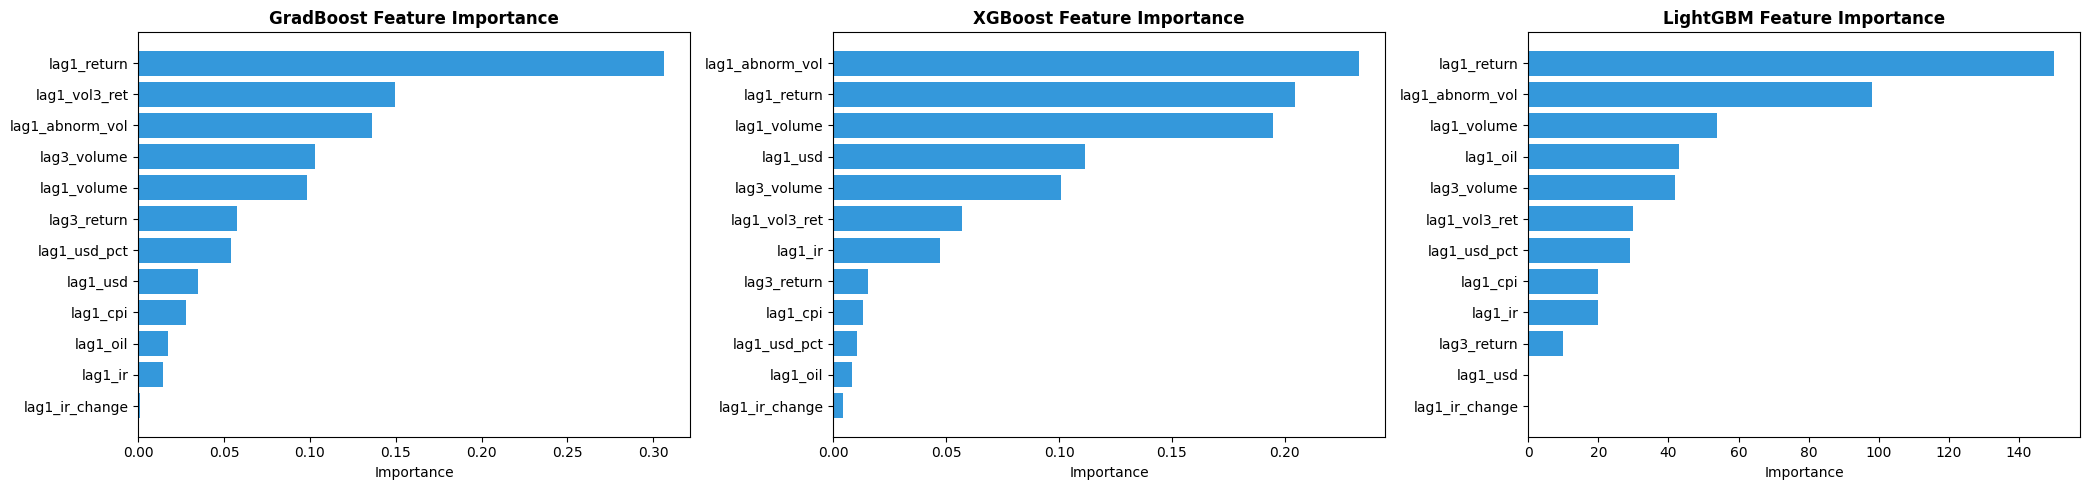

  → saved: d:\roohan\fyp-indexfunds\enhanced\v5\output\07_linear_coefficients.png


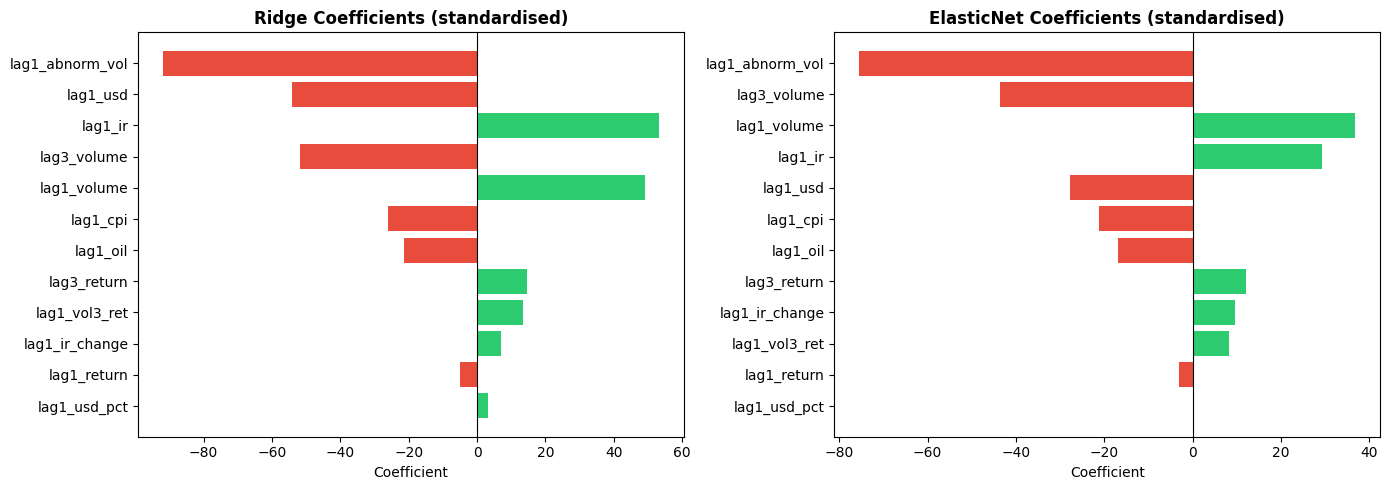

In [20]:
# Tree model feature importance
tree_models = [(n, m) for n, m in models.items() if hasattr(m, 'feature_importances_')]
n_tree = len(tree_models)
fig, axes = plt.subplots(1, n_tree, figsize=(7*n_tree, 5))
if n_tree == 1:
    axes = [axes]
for ax, (name, mdl) in zip(axes, tree_models):
    imps  = mdl.feature_importances_
    order = np.argsort(imps)
    ax.barh([FEATURES[i] for i in order], [imps[i] for i in order],
            color='#3498db', edgecolor='none')
    ax.set_title(f'{name} Feature Importance', fontweight='bold')
    ax.set_xlabel('Importance')
plt.tight_layout()
save_fig('06_feature_importance')

# Linear model coefficients
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, name in zip(axes, ['Ridge', 'ElasticNet']):
    coefs = models[name].named_steps['model'].coef_
    order = np.argsort(np.abs(coefs))
    bar_c = ['#e74c3c' if coefs[i] < 0 else '#2ecc71' for i in order]
    ax.barh([FEATURES[i] for i in order], [coefs[i] for i in order],
            color=bar_c, edgecolor='none')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{name} Coefficients (standardised)', fontweight='bold')
    ax.set_xlabel('Coefficient')
plt.tight_layout()
save_fig('07_linear_coefficients')


## 14. 6-Month Forward Forecast

**Assumptions (documented):**
- Macro features (`lag1_ir`, `lag1_oil`, `lag1_usd`, `lag1_cpi`) held at last known values
- `lag1_return` and `lag1_volume` are updated each step using the ensemble prediction
- Direction signal is reliable; magnitude estimates are not at this training size


In [21]:
# Retrain on full dataset
for name, mdl in models.items():
    mdl.fit(X, y)

last_row     = model_df.iloc[-1]
last_date    = last_row['date']
future_dates = pd.date_range(last_date + pd.offsets.MonthEnd(1),
                              periods=FORECAST_MONTHS, freq='ME')

base_feats  = {f: float(last_row[f]) for f in FEATURES}
prev_return = float(last_row['log_return'])
prev_volume = float(last_row['total_volume'])

forecast_rows = []
for fdate in future_dates:
    row = base_feats.copy()
    row['lag1_return'] = prev_return
    row['lag1_volume'] = prev_volume
    X_fut   = np.array([[row[f] for f in FEATURES]])
    m_preds = {name: float(mdl.predict(X_fut)[0]) for name, mdl in models.items()}
    ensemble = float(np.mean(list(m_preds.values())))
    n_pos    = sum(1 for p in m_preds.values() if p > 0)
    forecast_rows.append({
        'date': fdate, 'ensemble': ensemble,
        'direction': 'INFLOW ↑' if ensemble > 0 else 'OUTFLOW ↓',
        'consensus': f'{n_pos}/{len(models)} models → inflow',
        **m_preds
    })
    flow_norm   = ensemble / (abs(y).mean() + 1e-9)
    prev_return = float(np.clip(flow_norm * 0.01, -0.05, 0.05))

forecast_df = pd.DataFrame(forecast_rows)
display(forecast_df[['date', 'ensemble', 'direction', 'consensus']].to_string(index=False))


'      date    ensemble direction           consensus\n2025-11-30 -186.676622 OUTFLOW ↓ 1/5 models → inflow\n2025-12-31 -188.278558 OUTFLOW ↓ 1/5 models → inflow\n2026-01-31 -188.279542 OUTFLOW ↓ 1/5 models → inflow\n2026-02-28 -188.279542 OUTFLOW ↓ 1/5 models → inflow\n2026-03-31 -188.279542 OUTFLOW ↓ 1/5 models → inflow\n2026-04-30 -188.279542 OUTFLOW ↓ 1/5 models → inflow'

  → saved: d:\roohan\fyp-indexfunds\enhanced\v5\output\08_forecast_6month.png


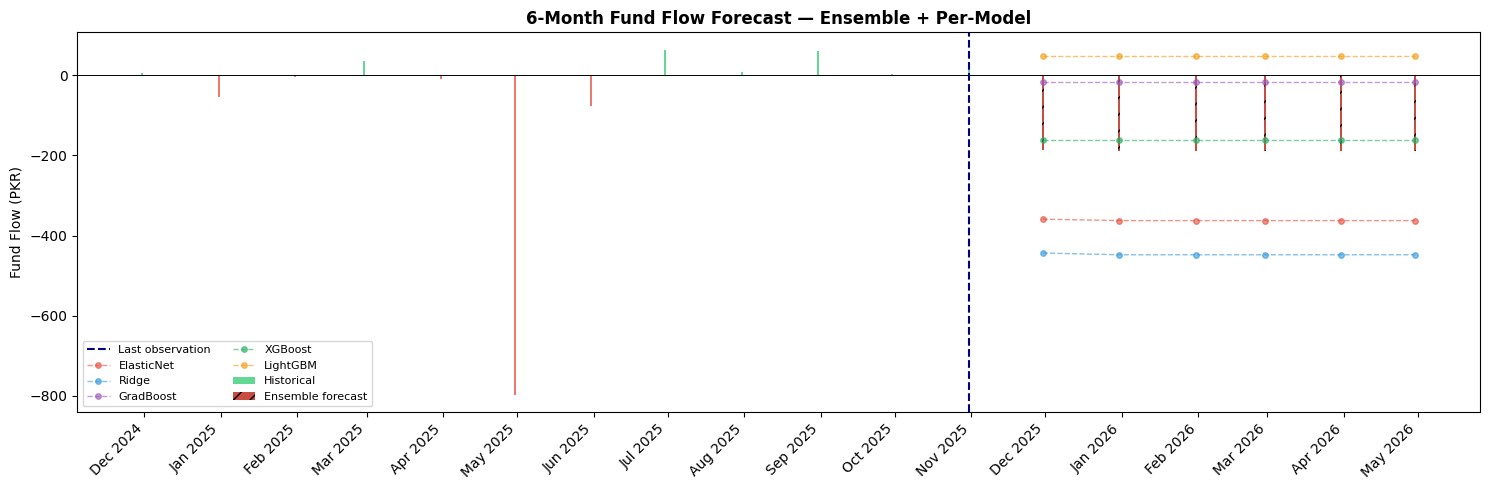

In [22]:
fig, ax = plt.subplots(figsize=(15, 5))
hist12    = model_df.tail(12)
ax.bar(hist12['date'], hist12[TARGET],
       color=np.where(hist12[TARGET] >= 0, '#2ecc71', '#e74c3c'), alpha=0.75, label='Historical')
fcolors = ['#27ae60' if v > 0 else '#c0392b' for v in forecast_df['ensemble']]
ax.bar(forecast_df['date'], forecast_df['ensemble'], color=fcolors, alpha=0.9,
       label='Ensemble forecast', hatch='//')
ax.axhline(0, color='black', linewidth=0.7)
ax.axvline(last_date, color='navy', linewidth=1.5, linestyle='--', label='Last observation')
for name, color in zip(MODEL_NAMES, MODEL_COLORS):
    if name in forecast_df.columns:
        ax.plot(forecast_df['date'], forecast_df[name], 'o--', color=color,
                linewidth=1, markersize=4, label=name, alpha=0.6)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=45, ha='right')
ax.set_title(f'{FORECAST_MONTHS}-Month Fund Flow Forecast — Ensemble + Per-Model',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Fund Flow (PKR)')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
save_fig('08_forecast_6month')


## 15. Portfolio Candidates — Company Selection

**Two ranking approaches:**
1. **By return** during historically positive fund flow months (from v4 — causal signal)
2. **By volume** during the same months (from v1-v3 — liquidity fallback)


  → saved: d:\roohan\fyp-indexfunds\enhanced\v5\output\09_company_selection.png


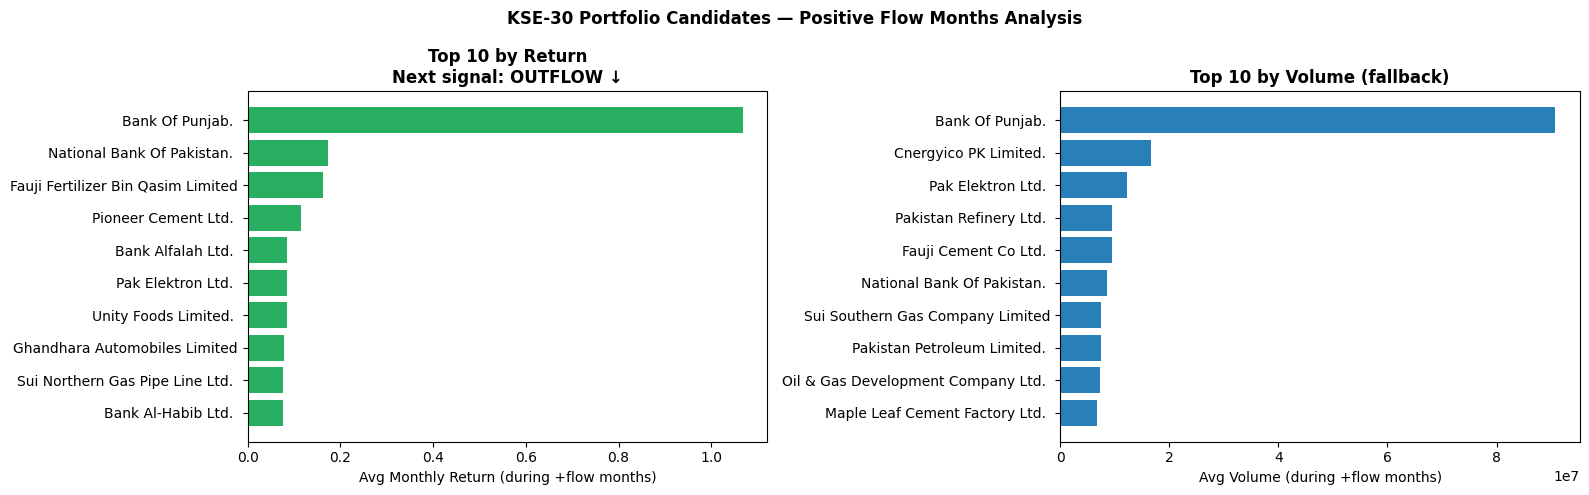


Top 10 by Return:


,Company,Avg Return
0,Bank Of Punjab.,1.067259
1,National Bank Of Pakistan.,0.173117
2,Fauji Fertilizer Bin Qasim Limited,0.162979
3,Pioneer Cement Ltd.,0.114679
4,Bank Alfalah Ltd.,0.084781
5,Pak Elektron Ltd.,0.084464
6,Unity Foods Limited.,0.084036
7,Ghandhara Automobiles Limited,0.079115
8,Sui Northern Gas Pipe Line Ltd.,0.076825
9,Bank Al-Habib Ltd.,0.075637



Top 10 by Volume:


,Company,Avg Volume
0,Bank Of Punjab.,9.077076e+07
1,Cnergyico PK Limited.,1.654205e+07
2,Pak Elektron Ltd.,1.218885e+07
3,Pakistan Refinery Ltd.,9.514198e+06
4,Fauji Cement Co Ltd.,9.388731e+06
5,National Bank Of Pakistan.,8.519716e+06
6,Sui Southern Gas Company Limited,7.505245e+06
7,Pakistan Petroleum Limited.,7.369222e+06
8,Oil & Gas Development Company Ltd.,7.329600e+06
9,Maple Leaf Cement Factory Ltd.,6.682955e+06


In [23]:
pos_periods = set(model_df.loc[model_df[TARGET] > 0, 'date'].dt.to_period('M'))
co_pos      = company_monthly[company_monthly['month'].isin(pos_periods)].dropna(subset=['return'])

avg_ret_pos  = co_pos.groupby('company')['return'].mean().sort_values(ascending=False)
top10_ret    = avg_ret_pos.head(10).reset_index()
top10_ret.columns = ['Company', 'Avg Return']

vol_pos     = co_raw[co_raw['date'].dt.to_period('M').isin(pos_periods)]
avg_vol_pos = vol_pos.groupby('company')['volume'].mean().sort_values(ascending=False)
top10_vol   = avg_vol_pos.head(10).reset_index()
top10_vol.columns = ['Company', 'Avg Volume']

next_dir = forecast_df['direction'].iloc[0]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
ax1.barh(top10_ret['Company'][::-1], top10_ret['Avg Return'][::-1],
         color='#27ae60', edgecolor='none')
ax1.set_xlabel('Avg Monthly Return (during +flow months)')
ax1.set_title(f'Top 10 by Return\nNext signal: {next_dir}', fontweight='bold')
ax2.barh(top10_vol['Company'][::-1], top10_vol['Avg Volume'][::-1],
         color='#2980b9', edgecolor='none')
ax2.set_xlabel('Avg Volume (during +flow months)')
ax2.set_title('Top 10 by Volume (fallback)', fontweight='bold')
plt.suptitle('KSE-30 Portfolio Candidates — Positive Flow Months Analysis',
             fontsize=12, fontweight='bold')
plt.tight_layout()
save_fig('09_company_selection')

print("\nTop 10 by Return:")
display(top10_ret)
print("\nTop 10 by Volume:")
display(top10_vol)


## 16. Market Efficiency Tests + Summary

In [24]:
# Hurst Exponent + Variance Ratio (from grok-v1)
series = model_df['log_return'].dropna().values
hurst  = hurst_exponent(series)
vr     = variance_ratio(series)

print(f"Hurst Exponent : {hurst:.3f}  "
      f"({'persistent — momentum signals viable' if hurst > 0.55 else 'near random walk'})")
print(f"Variance Ratio : {vr:.3f}  "
      f"({'positive autocorrelation' if vr > 1.1 else 'near random walk'})")

# Final summary
best_cv   = min(MODEL_NAMES, key=lambda n: np.mean(cv_results[n]['rmse']))
best_hold = min(MODEL_NAMES, key=lambda n: holdout_metrics[n]['RMSE'])
best_da   = max(MODEL_NAMES, key=lambda n: holdout_metrics[n]['DirAcc'])

print("\n" + "="*62)
print("  ENHANCED-V5 SUMMARY")
print("="*62)
print(f"  Training window : {model_df['date'].min().date()} → {model_df['date'].max().date()}")
print(f"  Rows used       : {len(model_df)}")
print(f"  Features        : {len(FEATURES)}  |  Models: {', '.join(MODEL_NAMES)}")
print(f"\n  Best CV RMSE    : {best_cv}  (mean = {np.mean(cv_results[best_cv]['rmse']):.1f})")
print(f"  Best holdout    : {best_hold}  (RMSE = {holdout_metrics[best_hold]['RMSE']:.1f})")
print(f"  Best direction  : {best_da}  (DA = {holdout_metrics[best_da]['DirAcc']:.0f}%)")
print(f"\n  Next month      : {forecast_df.iloc[0]['direction']}")
print(f"  Ensemble pred   : {forecast_df.iloc[0]['ensemble']:+.1f} PKR")
print(f"  Consensus       : {forecast_df.iloc[0]['consensus']}")
print("="*62)
print(f"\n  Plots saved → {OUT_DIR}")
print("  ⚠  Directional signal only — magnitude unreliable at this dataset size.")


Hurst Exponent : 0.386  (near random walk)
Variance Ratio : 0.251  (near random walk)

  ENHANCED-V5 SUMMARY
  Training window : 2021-11-30 → 2025-10-31
  Rows used       : 48
  Features        : 12  |  Models: ElasticNet, Ridge, GradBoost, XGBoost, LightGBM

  Best CV RMSE    : LightGBM  (mean = 152.2)
  Best holdout    : Ridge  (RMSE = 240.6)
  Best direction  : GradBoost  (DA = 60%)

  Next month      : OUTFLOW ↓
  Ensemble pred   : -186.7 PKR
  Consensus       : 1/5 models → inflow

  Plots saved → d:\roohan\fyp-indexfunds\enhanced\v5\output
  ⚠  Directional signal only — magnitude unreliable at this dataset size.
